<div style="background:white;padding:30px;text-align:center;">

# **German Traffic Sign Recognition with Deep Learning**

## **Course: Deep Learning**

### **Project Members**
### **Abdulrahman Aqili &nbsp; &amp; &nbsp; Ali Al-Qarni**

</div>


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **1. Project Introduction**

We built a system that **looks at a photo of a German road sign and tells us what sign it is** (Stop, Yield, 50 km/h, etc.).

**Goal:** train a computer-vision model that classifies traffic signs into one of **43 categories**.

**Expected outputs:**
- A trained model that reaches **high accuracy** on unseen test images.
- A clear **comparison** between a model we designed ourselves (Custom CNN) and a famous pre-trained model (ResNet-50).
- **Visual predictions** showing which sign the model thinks each image is, plus its confidence.

**Why it matters:** traffic-sign recognition is a core building block of self-driving cars and driver-assistance systems.

</div>


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **2. The Dataset – GTSRB**

We use the **German Traffic Sign Recognition Benchmark (GTSRB)**, a standard public dataset.

- **43 classes** of real traffic signs (speed limits, warnings, mandatory signs…).
- **~39,000** training images and **~12,000** test images.
- Photos taken in real driving conditions: different lighting, angles, weather, partial blur.
- Images are small color photos; we resize them all to **64 × 64 pixels**.

The chart below shows how many images each class has — some classes are much more common than others (class imbalance).

</div>


<div style="text-align:center;background:white;padding:10px;">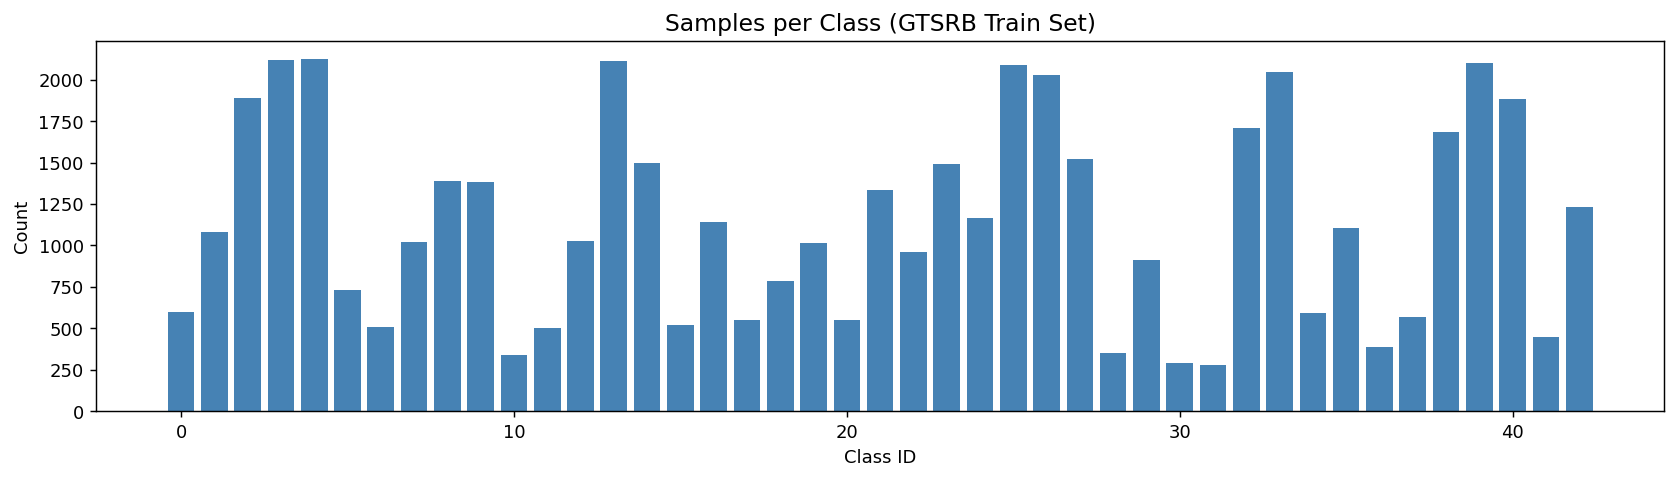<p style="font-size:15px;color:#555;margin-top:8px;"><em>Number of samples per class in the training set.</em></p></div>

<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **3. Tools & Models We Used**

**Frameworks & libraries**
- **PyTorch** – the deep-learning framework (defines the network, runs training on GPU).
- **torchvision** – ready-made datasets, image transforms, and pre-trained models.
- **scikit-learn** – metrics (confusion matrix, classification report).
- **matplotlib** – charts and visualisations.

**Two models we compare**
1. **Custom CNN** – a Convolutional Neural Network we designed from scratch.
2. **ResNet-50 (Transfer Learning)** – a famous 50-layer network pre-trained on ImageNet; we freeze it and re-train only the final layer for our 43 classes.

</div>


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **4.1 Data Preparation & Augmentation**

Before training, every image is prepared the same way:
- **Resize** all images to a fixed size **64 × 64**.
- **Normalize** colors using ImageNet mean/std (helps the network learn faster).

**Only on the training set**, we apply random **data augmentation** so the model sees more variety and does not memorize:
- Small **rotations**, **translations**, **scaling**, and **shear** (signs are rarely perfectly straight).
- Random changes in **brightness, contrast, saturation** (different weather and lighting).

We split the data into **Train / Validation / Test** so we can fairly measure how well the model works on **unseen** images.

</div>


<div style="background:white;padding:20px;font-size:18px;">

## **4. Model 1 – Custom CNN**

Three convolutional blocks that gradually learn richer visual features, followed by a small classifier.

**Layer-by-layer**
- **Block 1:** `Conv 3→32` → BatchNorm → ReLU → `Conv 32→32` → MaxPool → Dropout *(learns edges & colors)*
- **Block 2:** `Conv 32→64` → … → MaxPool → Dropout *(learns shapes & corners)*
- **Block 3:** `Conv 64→128` → … → MaxPool → Dropout *(learns sign-like patterns)*
- **Global Average Pooling** turns the feature map into a single vector.
- **Classifier:** `Linear 128→256` → ReLU → Dropout 0.5 → `Linear 256→43`.

**Activation:** **ReLU** everywhere (fast, avoids vanishing gradients).
**Regularisation:** BatchNorm + Dropout to fight overfitting.

</div>


In [ ]:
# Custom CNN — three Conv-BN-ReLU blocks + Global Average Pooling + classifier
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch,  out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout(0.25),
            )
        self.block1 = block(3, 32)      # learns edges / colors
        self.block2 = block(32, 64)     # learns shapes
        self.block3 = block(64, 128)    # learns sign patterns
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256), nn.BatchNorm1d(256),
            nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, num_classes),   # 43 traffic-sign classes
        )

    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)


<div style="background:white;padding:20px;font-size:18px;">

## **5. Model 2 – ResNet-50 (Transfer Learning)**

Instead of training a giant network from zero, we **reuse a model that already learned from millions of images** (ImageNet).

- Load **ResNet-50** with pre-trained weights.
- **Freeze** all the original layers (`requires_grad = False`) — we keep their knowledge.
- **Replace the final layer** with a new `Linear(…, 43)` for our traffic signs.
- Only this last layer is trained → fast and very accurate.

This technique is called **Transfer Learning**.

</div>


In [ ]:
# ResNet-50 with frozen backbone, new head for 43 traffic-sign classes
resnet_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Freeze every pretrained layer — keep the knowledge from ImageNet
for p in resnet_model.parameters():
    p.requires_grad = False

# Replace the original 1000-class head with a new one for 43 classes
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, NUM_CLASSES)
resnet_model = resnet_model.to(DEVICE)


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **5.1 Training Setup**

- **Loss function:** `CrossEntropyLoss` with **label smoothing 0.05** (prevents over-confidence).
- **Optimizer:** **Adam** with weight decay (regularization).
- **Scheduler:** **Cosine annealing** — learning rate slowly decreases each epoch.
- **Gradient clipping** at 1.0 — keeps training stable.
- **Early stopping** with patience = 5 — automatically stops if validation stops improving.
- We always save the **best model** (highest validation accuracy) to disk.

</div>


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **6. Results**

### Training curves
Both models converge quickly. **ResNet-50** starts higher and reaches a lower loss because of its pre-trained features.

</div>


<div style="text-align:center;background:white;padding:10px;">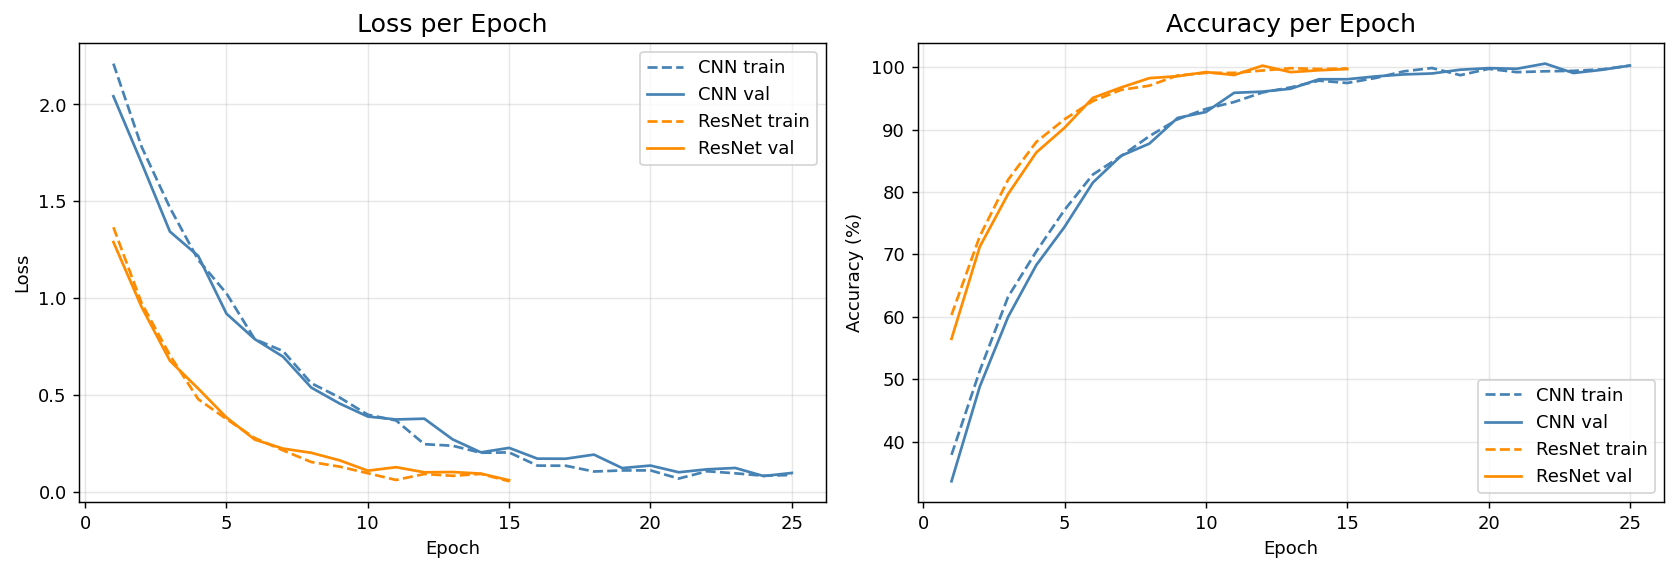<p style="font-size:15px;color:#555;margin-top:8px;"><em>Loss and accuracy across epochs — Custom CNN vs ResNet-50.</em></p></div>

<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

### Confusion matrices
A bright diagonal = the model predicts the correct class. Both models show very strong diagonals; ResNet-50 is slightly cleaner.

</div>


<div style="text-align:center;background:white;padding:10px;">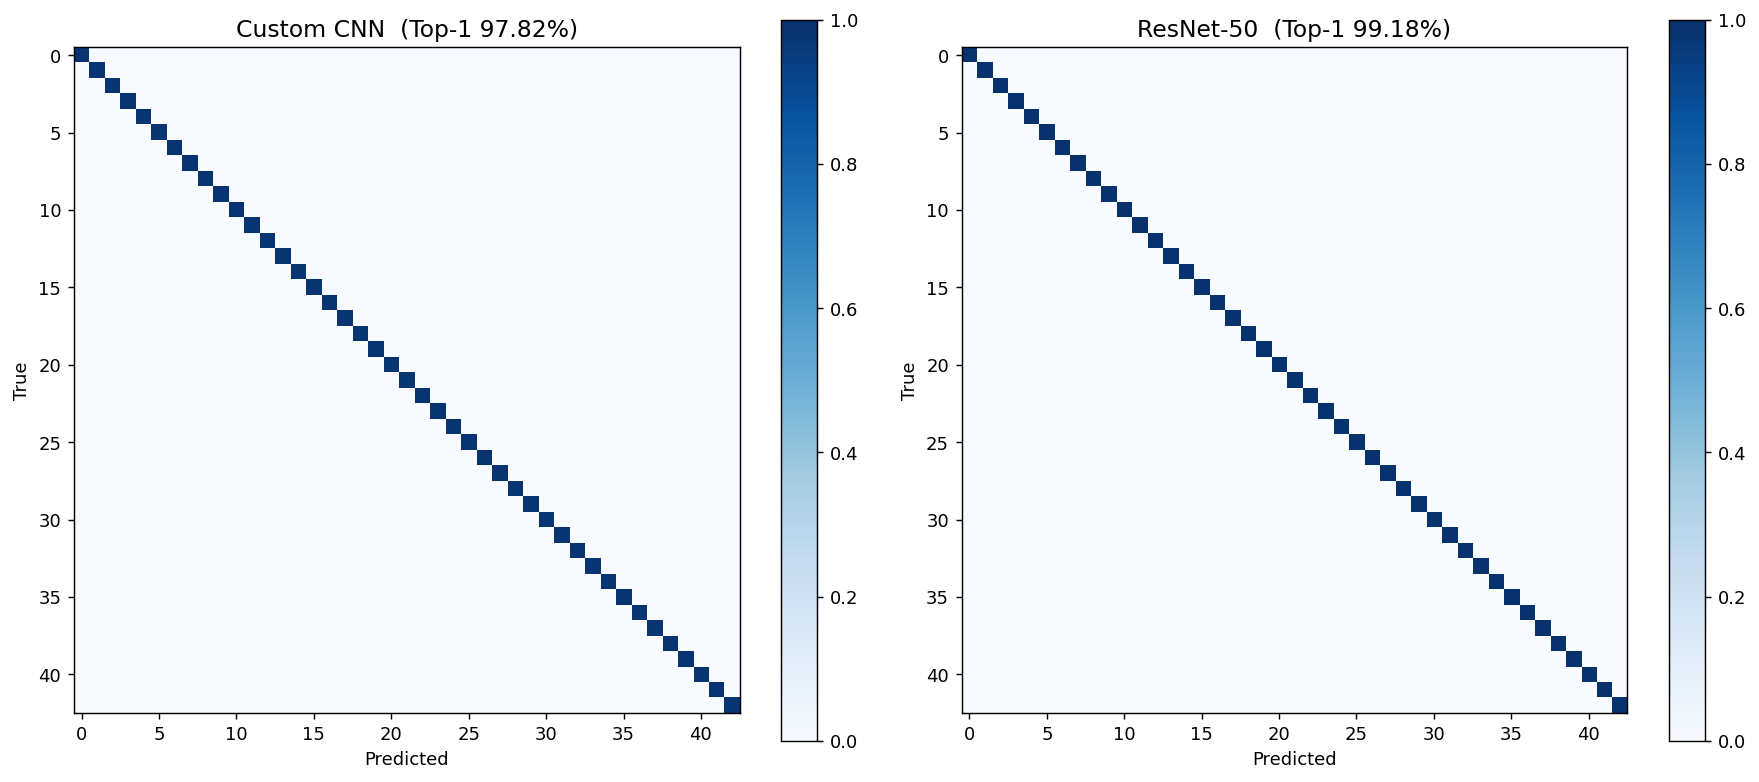<p style="font-size:15px;color:#555;margin-top:8px;"><em>Normalized confusion matrices on the test set.</em></p></div>

<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

### Final benchmark – the most important chart

</div>


<div style="text-align:center;background:white;padding:10px;">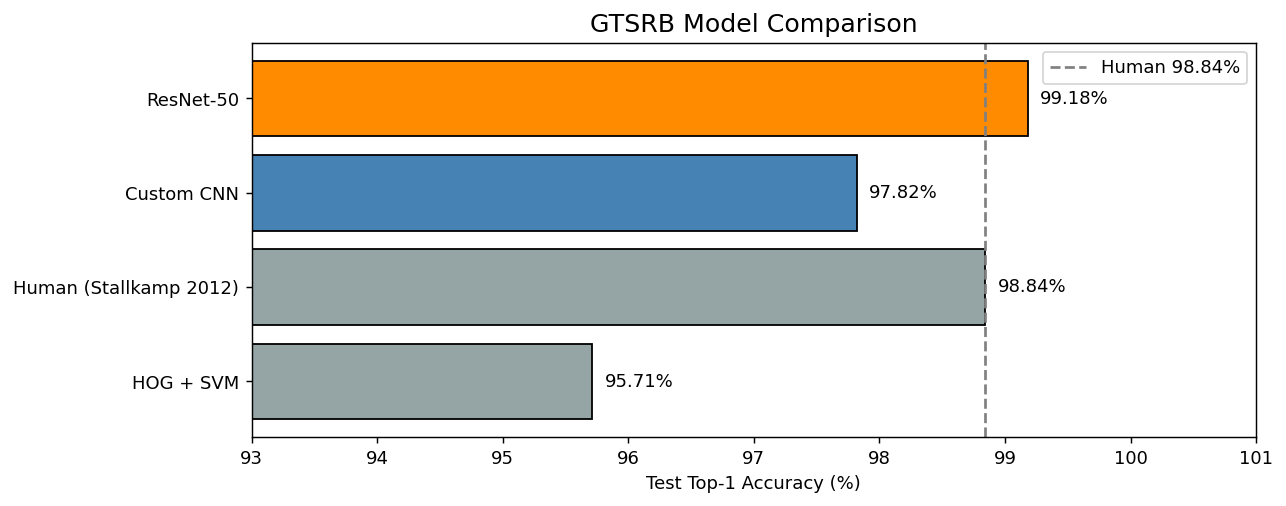<p style="font-size:15px;color:#555;margin-top:8px;"><em>Test Top-1 accuracy compared to classical methods and human performance.</em></p></div>

<div style="background:white;padding:20px;font-size:20px;line-height:1.8;">

### Headline numbers

| Metric | Custom CNN | ResNet-50 |
|---|---|---|
| **Top-1 Accuracy** | **97.82 %** | **99.18 %** |
| **Top-5 Accuracy** | 99.74 % | 99.96 % |
| **Parameters** | ~0.46 M | ~23.6 M |

**ResNet-50 beats human-level performance (98.84 %).**

</div>


<div style="background:white;padding:20px;font-size:18px;line-height:1.6;">

## **6.1 Sample Predictions on Real Test Images**

For each image we show the **photo** and a caption telling us what the model thinks the sign is, for example:

> **This sign indicates: "Speed limit (70km/h)"  —  Confidence: 98.4%**

A **green** title means the model was **correct**, a **red** title means it was wrong (and we also show the true class).

</div>


In [ ]:
# Sample predictions on the test set
# For each image we print the picture and a caption like:
#   "This sign indicates: Speed limit (70km/h)   (98.4%)"
# Green title = correct prediction, Red title = wrong prediction.

cnn_model.load_state_dict(torch.load('best_cnn.pt',    map_location=DEVICE))
resnet_model.load_state_dict(torch.load('best_resnet.pt', map_location=DEVICE))
cnn_model.eval(); resnet_model.eval()

sample_ids = random.sample(range(len(test_raw)), 8)

def show_predictions(model, model_name, header_color):
    fig, axes = plt.subplots(2, 4, figsize=(16, 9))
    fig.suptitle(f'{model_name} — Sample Test Predictions',
                 fontsize=15, fontweight='bold', color=header_color)
    for ax, idx in zip(axes.flat, sample_ids):
        img_pil, true_label = test_raw[idx]
        x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs = F.softmax(model(x), dim=1)[0].cpu().numpy()
        pred = int(probs.argmax())
        conf = float(probs[pred]) * 100
        correct = (pred == true_label)

        ax.imshow(img_pil)
        ax.axis('off')
        caption = f'This sign indicates:\n"{CLASS_NAMES[pred]}"\nConfidence: {conf:.1f}%'
        if not correct:
            caption += f'\n(True: {CLASS_NAMES[true_label]})'
        ax.set_title(caption, fontsize=10,
                     color=('#1e8449' if correct else '#c0392b'),
                     fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(cnn_model,    'Custom CNN', '#2874a6')
show_predictions(resnet_model, 'ResNet-50',  '#b9770e')


<div style="background:white;padding:25px;font-size:19px;line-height:1.7;">

## **7. Conclusion**

- We trained **two deep-learning models** on the GTSRB traffic-sign dataset.
- Our **Custom CNN** — a small network built from scratch — already reaches **~97.8 %** accuracy.
- **ResNet-50 with transfer learning** pushes accuracy to **~99.2 %**, surpassing the human benchmark.
- **Key takeaway:** transfer learning from a strong pre-trained model gives **higher accuracy with less training**, while a well-designed custom CNN is still a great lightweight option.

### **Thank you!  Questions?**

</div>
